# OCR sobre fotos propias — YOLO26s-seg + EasyOCR + PaddleOCR

Alcance de este notebook, sin nada de más:

1. Cargar el checkpoint ya entrenado de **YOLO26s-seg** (`pesos/yolo26s_seg/mejor_map50.pt`) y correr inferencia sobre **tus 2 fotos propias** (no reentrena nada).
2. Recortar cada lomo detectado, enderezado a su eje.
3. Leer el texto de cada recorte con **EasyOCR** y **PaddleOCR**.
4. Armar una tabla comparando lo que leyó cada motor, lado a lado.

No incluye catálogo ni auditoría — eso se agrega después, una vez que se vea cuál de los dos motores lee mejor.


## 1) Instalación

In [1]:
import sys
print(sys.executable)

c:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCII-TP-evaluacion\.venv\Scripts\python.exe


In [2]:
#%pip install -q opencv-python-headless numpy pandas matplotlib ultralytics easyocr paddleocr paddlepaddle rapidfuzz openpyxl


## 2) Configuración

Poné tus 2 fotos en la carpeta `fotos_propias/`, en la raíz del repo (al lado de `dataset/` y `pesos/`).


In [3]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Localiza la raíz del repo (busca concepto/Plan.md) — misma lógica que los notebooks de los 4 modelos.
def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


RAIZ = raiz_del_repo()
CHECKPOINT_PATH = RAIZ / "pesos" / "yolo26s_seg" / "mejor_map50.pt"
FOTOS_DIR = RAIZ / "fotos_propias"
FOTOS_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = RAIZ / "resultados_ocr"
CROPS_DIR = OUT_DIR / "recortes"
CROPS_DIR.mkdir(parents=True, exist_ok=True)

CATALOGO_XLSX = RAIZ / "catalogo" / "catalogo.xlsx"

print("Raíz del repo:", RAIZ)
print("Checkpoint:", CHECKPOINT_PATH, "| existe:", CHECKPOINT_PATH.exists())
print("Catálogo:", CATALOGO_XLSX, "| existe:", CATALOGO_XLSX.exists())

fotos = sorted(FOTOS_DIR.glob("*.jpg")) + sorted(FOTOS_DIR.glob("*.jpeg")) + sorted(FOTOS_DIR.glob("*.png"))
print(f"Fotos encontradas en {FOTOS_DIR}: {len(fotos)}")
for f in fotos:
    print(" -", f.name)
if not fotos:
    print("⚠️  Poné tus 2 fotos en esa carpeta (.jpg/.jpeg/.png) y volvé a correr esta celda.")


Raíz del repo: C:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCII-TP-evaluacion
Checkpoint: C:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCII-TP-evaluacion\pesos\yolo26s_seg\mejor_map50.pt | existe: True
Catálogo: C:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCII-TP-evaluacion\catalogo\catalogo.xlsx | existe: True
Fotos encontradas en C:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCII-TP-evaluacion\fotos_propias: 2
 - estante1.jpg
 - estante2.jpg


## 3) Detección y segmentación (YOLO26s-seg)

In [4]:
from ultralytics import YOLO

modelo = YOLO(str(CHECKPOINT_PATH))

CONF = 0.50
IOU = 0.40

resultados = modelo.predict(source=[str(f) for f in fotos], conf=CONF, iou=IOU, save=False, verbose=False)

total_lomos = sum(len(r.masks.xy) if r.masks is not None else 0 for r in resultados)
print(f"{len(resultados)} foto(s) procesadas, {total_lomos} lomos detectados en total")


2 foto(s) procesadas, 19 lomos detectados en total


## 4) Recorte de cada lomo (enderezado a su eje)

In [5]:
def crop_from_polygon(img, pts):
    """Recorta siguiendo el polígono predicho: rectángulo mínimo rotado + enderezado."""
    pts = np.array(pts, dtype=np.float32)
    (cx, cy), (rw, rh), angle = cv2.minAreaRect(pts)
    if rw < rh:
        rw, rh = rh, rw
        angle += 90

    M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    h, w = img.shape[:2]
    rotated = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    x1, y1 = int(cx - rw / 2), int(cy - rh / 2)
    x2, y2 = int(cx + rw / 2), int(cy + rh / 2)
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    return rotated[y1:y2, x1:x2]


def preprocess_crop(crop, min_width=80):
    """Reescala (ancho mínimo) y mejora contraste (CLAHE) antes del OCR."""
    h, w = crop.shape[:2]
    if w < min_width and w > 0:
        scale = min_width / w
        crop = cv2.resize(crop, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_CUBIC)
    lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)


In [6]:
registros = []
for r in resultados:
    img_path = Path(r.path)
    img = cv2.imread(str(img_path))
    if r.masks is None:
        continue
    for i, poly in enumerate(r.masks.xy):
        crop = crop_from_polygon(img, poly)
        if crop.size == 0:
            continue
        crop = preprocess_crop(crop)
        crop_id = f"{img_path.stem}_{i:03d}"
        out_path = CROPS_DIR / f"{crop_id}.jpg"
        cv2.imwrite(str(out_path), crop)
        registros.append({"crop_id": crop_id, "imagen_origen": img_path.name, "crop_path": str(out_path)})

crops_df = pd.DataFrame(registros)
print(f"{len(crops_df)} recortes guardados en {CROPS_DIR}")
crops_df.head()


19 recortes guardados en C:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCII-TP-evaluacion\resultados_ocr\recortes


,crop_id,imagen_origen,crop_path
0,estante1_000,estante1.jpg,C:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCI...
1,estante1_001,estante1.jpg,C:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCI...
2,estante1_002,estante1.jpg,C:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCI...
3,estante1_003,estante1.jpg,C:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCI...
4,estante1_004,estante1.jpg,C:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCI...


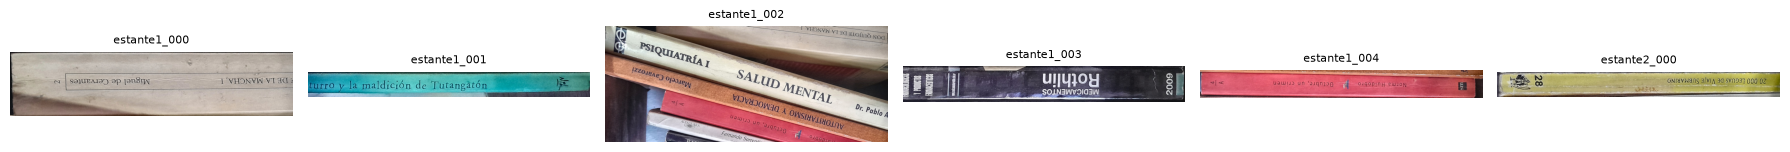

In [7]:
# Vista rápida de los recortes
if len(crops_df) > 0:
    n = min(6, len(crops_df))
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))
    for ax, (_, row) in zip(np.atleast_1d(axes), crops_df.head(n).iterrows()):
        img = cv2.cvtColor(cv2.imread(row["crop_path"]), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(row["crop_id"], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 5) OCR: EasyOCR y PaddleOCR

In [8]:


import sys
print("Using Python:", sys.executable)

try:
    import paddle
    print("Paddle imported successfully from:", paddle.__file__)
except Exception as e:
    print("CRITICAL IMPORT ERROR:", e)

Using Python: c:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCII-TP-evaluacion\.venv\Scripts\python.exe


c:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCII-TP-evaluacion\.venv\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Paddle imported successfully from: c:\Users\IanEz\Documents\ReposGitHub\DVxC-VcCII-TP-evaluacion\.venv\Lib\site-packages\paddle\__init__.py


In [9]:
import time
import torch
import easyocr
import os

from paddleocr import PaddleOCR # Import this AFTER setting the environment variable

# You must also explicitly disable mkldnn when initializing your model
ocr = PaddleOCR(lang='en',enable_mkldnn=False)

usar_gpu = torch.cuda.is_available()
print("GPU disponible:", usar_gpu)

easyocr_reader = easyocr.Reader(["es", "en"], gpu=usar_gpu)

# API de PaddleOCR 3.x: use_textline_orientation (antes use_angle_cls), sin show_log,
# y .predict() en vez de .ocr() (devuelve rec_texts/rec_scores, no listas anidadas).
paddleocr_reader = PaddleOCR(use_textline_orientation=True, lang="es")


def leer_easyocr(img_bgr):
    resultado = easyocr_reader.readtext(img_bgr)
    if not resultado:
        return "", 0.0
    texto = " ".join(r[1] for r in resultado)
    confianza = float(np.mean([r[2] for r in resultado]))
    return texto.strip(), confianza


def _obtener(res, clave):
    """PaddleOCR 3.x devuelve objetos tipo dict; soporta ambas formas de acceso."""
    try:
        return res[clave]
    except (TypeError, KeyError):
        return getattr(res, clave, None)


def leer_paddleocr(img_bgr):
    resultado = paddleocr_reader.predict(img_bgr)
    if not resultado:
        return "", 0.0
    res = resultado[0]
    textos = _obtener(res, "rec_texts") or []
    scores = _obtener(res, "rec_scores") or []
    if not textos:
        return "", 0.0
    texto = " ".join(textos)
    confianza = float(np.mean(scores)) if scores else 0.0
    return texto.strip(), confianza


def leer_mejor_rotacion(img_bgr, funcion_lectura, rotaciones=(0, 90, 270)):
    """Prueba 0°/90°/270° y se queda con la lectura de mayor confianza."""
    mejor_texto, mejor_conf, mejor_rot = "", -1.0, 0
    for rot in rotaciones:
        if rot == 0:
            rotada = img_bgr
        else:
            codigo = {90: cv2.ROTATE_90_CLOCKWISE, 270: cv2.ROTATE_90_COUNTERCLOCKWISE}[rot]
            rotada = cv2.rotate(img_bgr, codigo)
        texto, conf = funcion_lectura(rotada)
        if conf > mejor_conf:
            mejor_texto, mejor_conf, mejor_rot = texto, conf, rot
    return mejor_texto, mejor_conf, mejor_rot


download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to C:\Users\IanEz/.paddleocr/whl\det\en\en_PP-OCRv3_det_infer\en_PP-OCRv3_det_infer.tar


100%|██████████| 4.00M/4.00M [00:28<00:00, 141kiB/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to C:\Users\IanEz/.paddleocr/whl\rec\en\en_PP-OCRv4_rec_infer\en_PP-OCRv4_rec_infer.tar


100%|██████████| 10.2M/10.2M [00:28<00:00, 355kiB/s] 


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to C:\Users\IanEz/.paddleocr/whl\cls\ch_ppocr_mobile_v2.0_cls_infer\ch_ppocr_mobile_v2.0_cls_infer.tar


...

[2026/10/06 11:23:13] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=True, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\IanEz/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\IanEz/.paddleocr/whl\\rec\\en\\en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6


[2026-10-06 11:23:27,124] [ WARNING] easyocr.py:71 - Using CPU. Note: This module is much faster with a GPU.


GPU disponible: False
download https://paddleocr.bj.bcebos.com/PP-OCRv3/multilingual/latin_PP-OCRv3_rec_infer.tar to C:\Users\IanEz/.paddleocr/whl\rec\latin\latin_PP-OCRv3_rec_infer\latin_PP-OCRv3_rec_infer.tar


100%|██████████| 10.2M/10.2M [00:11<00:00, 884kiB/s] 

[2026/10/06 11:23:45] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=True, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\IanEz/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\IanEz/.paddleocr/whl\\rec\\latin\\latin_PP-OCRv3_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch

## 6) Comparar EasyOCR vs PaddleOCR, recorte por recorte

In [11]:
def leer_paddleocr(img_bgr):
    # Use .ocr() instead of .predict(). 
    # cls=False because you are already handling rotation manually in leer_mejor_rotacion
    resultado = paddleocr_reader.ocr(img_bgr, cls=False)
    
    # Check if the result is empty or None
    if not resultado or not resultado[0]:
        return "", 0.0
    
    textos = []
    confianzas = []
    
    # Loop through all detected lines in the image
    for linea in resultado[0]:
        # Structure: [[box_coords], ('Text', confidence)]
        caja, (texto, conf) = linea 
        textos.append(texto)
        confianzas.append(conf)
        
    if not textos:
        return "", 0.0
        
    # Join multiple lines of text if found, and average their confidence
    texto_final = " ".join(textos)
    conf_final = sum(confianzas) / len(confianzas)
    
    return texto_final, conf_final

In [12]:
filas = []
for _, row in crops_df.iterrows():
    img = cv2.imread(row["crop_path"])

    t0 = time.time()
    texto_easy, conf_easy, rot_easy = leer_mejor_rotacion(img, leer_easyocr)
    latencia_easy = (time.time() - t0) * 1000

    t0 = time.time()
    texto_paddle, conf_paddle, rot_paddle = leer_mejor_rotacion(img, leer_paddleocr)
    latencia_paddle = (time.time() - t0) * 1000

    filas.append({
        "crop_id": row["crop_id"],
        "imagen_origen": row["imagen_origen"],
        "easyocr_texto": texto_easy,
        "easyocr_confianza": round(conf_easy, 3),
        "easyocr_latencia_ms": round(latencia_easy, 1),
        "paddleocr_texto": texto_paddle,
        "paddleocr_confianza": round(conf_paddle, 3),
        "paddleocr_latencia_ms": round(latencia_paddle, 1),
    })

comparativa_df = pd.DataFrame(filas)
comparativa_df.to_csv(OUT_DIR / "comparativa_ocr.csv", index=False)
comparativa_df


[2026/10/06 11:28:08] ppocr DEBUG: dt_boxes num : 2, elapsed : 1.7382473945617676
[2026/10/06 11:28:09] ppocr DEBUG: rec_res num  : 2, elapsed : 0.4742889404296875
[2026/10/06 11:28:09] ppocr DEBUG: dt_boxes num : 3, elapsed : 0.12475323677062988
[2026/10/06 11:28:09] ppocr DEBUG: rec_res num  : 3, elapsed : 0.07473635673522949
[2026/10/06 11:28:09] ppocr DEBUG: dt_boxes num : 3, elapsed : 0.06931376457214355
[2026/10/06 11:28:09] ppocr DEBUG: rec_res num  : 3, elapsed : 0.05980634689331055
[2026/10/06 11:28:37] ppocr DEBUG: dt_boxes num : 2, elapsed : 0.28218913078308105
[2026/10/06 11:28:37] ppocr DEBUG: rec_res num  : 2, elapsed : 0.06907081604003906
[2026/10/06 11:28:37] ppocr DEBUG: dt_boxes num : 2, elapsed : 0.13249754905700684
[2026/10/06 11:28:37] ppocr DEBUG: rec_res num  : 2, elapsed : 0.07686018943786621
[2026/10/06 11:28:37] ppocr DEBUG: dt_boxes num : 2, elapsed : 0.059950828552246094
[2026/10/06 11:28:37] ppocr DEBUG: rec_res num  : 2, elapsed : 0.05948185920715332
[2026

,crop_id,imagen_origen,easyocr_texto,easyocr_confianza,easyocr_latencia_ms,paddleocr_texto,paddleocr_confianza,paddleocr_latencia_ms
0,estante1_000,estante1.jpg,2 1 9 1 = 1,0.675,65811.9,"DE LA MANCHA,I Miguel de Cervantes",0.933,2578.4
1,estante1_001,estante1.jpg,1 5 1 2 1 FN,0.563,27232.2,turro y la maldición de Tutangatón,0.916,714.7
2,estante1_002,estante1.jpg,Id IOlinò 1 4 Dr. A ( FHONVW VT NOa PSIQUIATRf...,0.532,200508.3,PSIQUIATRIAI SALUD MENTAI +/A Dr.Pablo ALFAGUA...,0.905,1298.2
3,estante1_003,estante1.jpg,TAUUUUN 1 PRD8I HNNH8M7MS 1 2009,0.349,44544.0,2009,1.000,577.9
4,estante1_004,estante1.jpg,4 [ 5 ; 1 f sm,0.627,48414.9,+A sm,0.913,635.0
5,estante2_000,estante2.jpg,8 8 { 5 é 1 28,0.706,30553.2,20.000 LEGUAS DE VIAJE SUBMARINO 28,0.971,600.7
6,estante2_001,estante2.jpg,90 6 1 5 4 1 5 É € ; 9 { PLAZA UANES,0.488,107746.6,Pablo De Santis,0.957,1003.4
7,estante2_002,estante2.jpg,[ 8 2 1 5 {,0.370,38112.8,LECCION DE BAILE DE LOS OSITOS TORMONT,0.977,688.8
8,estante2_003,estante2.jpg,5 AVENTURAS de TOM SAWYER Mark Twain BILLIKEN,0.772,48057.5,17 AVENTURAS de TOM SAWYER_ Mark Twain BILLIKEN,0.986,714.6
9,estante2_004,estante2.jpg,ALFAGUARA Carlos Rodrigues Gesualdi Raros pein...,0.868,38513.5,ALFAGUARA Carlos Rodrigues Gesualdi Raros pein...,0.985,659.7


In [13]:
# Resumen: confianza y latencia promedio de cada motor (no reemplaza mirar la tabla de arriba a ojo)
resumen = pd.DataFrame({
    "motor": ["easyocr", "paddleocr"],
    "confianza_media": [comparativa_df["easyocr_confianza"].mean(), comparativa_df["paddleocr_confianza"].mean()],
    "latencia_media_ms": [comparativa_df["easyocr_latencia_ms"].mean(), comparativa_df["paddleocr_latencia_ms"].mean()],
})
resumen


,motor,confianza_media,latencia_media_ms
0,easyocr,0.565053,48891.421053
1,paddleocr,0.948842,649.231579


## 7) Comparar contra el catálogo (`catalogo/catalogo.xlsx`)

Para cada recorte, busca el título más parecido dentro del catálogo (comparación difusa, tolera errores de OCR, mayúsculas, acentos) y marca si el texto leído **coincide** con algún libro real del catálogo o no — por separado para EasyOCR y para PaddleOCR. Esto no asume que el motor "sabe" qué libro es; solo mide si lo que leyó se parece lo suficiente a un título real como para identificarlo.


In [15]:
from rapidfuzz import fuzz, process

UMBRAL_COINCIDENCIA = 85  # 0-100; subir si da falsos positivos, bajar si no encuentra coincidencias reales

catalogo_df = pd.read_excel(CATALOGO_XLSX)
catalogo_df.columns = [c.strip().lower() for c in catalogo_df.columns]  # por si vienen con mayúsculas/espacios
print(f"{len(catalogo_df)} libros en el catálogo")
catalogo_df.head()


29 libros en el catálogo


,titulo,autor
0,El reñidero ELECTRA,SEGIO DE CRECCO - SOFOCLES
1,EL PRINCIPE,Maquinavelo
2,La máquina del tiempo,Hernert G. Wells
3,Los árboles mueren de pie,Alejandro Casona
4,Rebelión en la granja,George Orwell


In [19]:
def mejor_match_catalogo(texto_leido, catalogo_df):
    texto_leido = str(texto_leido).strip().upper()
    
    if catalogo_df.empty or not texto_leido:
        return None, None, 0
    
    titulos = catalogo_df["titulo"].astype(str).str.upper().tolist()
    #match, score, idx = process.extractOne(texto_leido, titulos, scorer=fuzz.token_sort_ratio)
    match, score, idx = process.extractOne(texto_leido, titulos, scorer=fuzz.token_set_ratio)
    autor = catalogo_df.iloc[idx]["autor"] if "autor" in catalogo_df.columns else None
    return match, autor, score


filas_catalogo = []
for _, row in comparativa_df.iterrows():
    titulo_easy, autor_easy, score_easy = mejor_match_catalogo(row["easyocr_texto"], catalogo_df)
    titulo_paddle, autor_paddle, score_paddle = mejor_match_catalogo(row["paddleocr_texto"], catalogo_df)

    filas_catalogo.append({
        "crop_id": row["crop_id"],
        "imagen_origen": row["imagen_origen"],

        "easyocr_texto": row["easyocr_texto"],
        "easyocr_match_titulo": titulo_easy,
        "easyocr_match_score": score_easy,
        "easyocr_coincide": score_easy >= UMBRAL_COINCIDENCIA,

        "paddleocr_texto": row["paddleocr_texto"],
        "paddleocr_match_titulo": titulo_paddle,
        "paddleocr_match_score": score_paddle,
        "paddleocr_coincide": score_paddle >= UMBRAL_COINCIDENCIA,
    })

catalogo_match_df = pd.DataFrame(filas_catalogo)
catalogo_match_df.to_csv(OUT_DIR / "comparativa_catalogo.csv", index=False)
catalogo_match_df


,crop_id,imagen_origen,easyocr_texto,easyocr_match_titulo,easyocr_match_score,easyocr_coincide,paddleocr_texto,paddleocr_match_titulo,paddleocr_match_score,paddleocr_coincide
0,estante1_000,estante1.jpg,2 1 9 1 = 1,CUENTOS DE LA SELVA,23.076923,False,"DE LA MANCHA,I Miguel de Cervantes",DON QUIJOTE DE LA MANCHA I,59.649123,False
1,estante1_001,estante1.jpg,1 5 1 2 1 FN,REBELIÓN EN LA GRANJA,27.586207,False,turro y la maldición de Tutangatón,GATURRO Y LA MALDICIÓN DE TUNTANGATÓN,95.774648,True
2,estante1_002,estante1.jpg,Id IOlinò 1 4 Dr. A ( FHONVW VT NOa PSIQUIATRf...,GATURRO Y LA MALDICIÓN DE TUNTANGATÓN,24.390244,False,PSIQUIATRIAI SALUD MENTAI +/A Dr.Pablo ALFAGUA...,GATURRO Y LA MANSIÓN DEL TERROR,36.956522,False
3,estante1_003,estante1.jpg,TAUUUUN 1 PRD8I HNNH8M7MS 1 2009,20000 LENGUAS DE VIAJE SUBMARINO,35.483871,False,2009,20000 LENGUAS DE VIAJE SUBMARINO,16.666667,False
4,estante1_004,estante1.jpg,4 [ 5 ; 1 f sm,DON QUIJOTE DE LA MANCHA I,30.000000,False,+A sm,NO PASÓ NADA,35.294118,False
5,estante2_000,estante2.jpg,8 8 { 5 é 1 28,DON QUIJOTE DE LA MANCHA I,26.315789,False,20.000 LEGUAS DE VIAJE SUBMARINO 28,20000 LENGUAS DE VIAJE SUBMARINO,92.537313,True
6,estante2_001,estante2.jpg,90 6 1 5 4 1 5 É € ; 9 { PLAZA UANES,GATURRO Y LA MANSIÓN DEL TERROR,31.746032,False,Pablo De Santis,EL LARILLO DE TORMES,51.428571,False
7,estante2_002,estante2.jpg,[ 8 2 1 5 {,DON QUIJOTE DE LA MANCHA I,27.027027,False,LECCION DE BAILE DE LOS OSITOS TORMONT,LECCIÓN DE BAILE DE LOS OSITOS,83.870968,False
8,estante2_003,estante2.jpg,5 AVENTURAS de TOM SAWYER Mark Twain BILLIKEN,AVENTURAS DE TOM SAWYER,100.000000,True,17 AVENTURAS de TOM SAWYER_ Mark Twain BILLIKEN,AVENTURAS DE TOM SAWYER,82.051282,False
9,estante2_004,estante2.jpg,ALFAGUARA Carlos Rodrigues Gesualdi Raros pein...,RAROS PEINADOS,100.000000,True,ALFAGUARA Carlos Rodrigues Gesualdi Raros pein...,RAROS PEINADOS,100.000000,True


In [20]:
# Resumen: cuántos recortes coincidieron con el catálogo, por motor
resumen_catalogo = pd.DataFrame({
    "motor": ["easyocr", "paddleocr"],
    "coincidencias": [catalogo_match_df["easyocr_coincide"].sum(), catalogo_match_df["paddleocr_coincide"].sum()],
    "total_recortes": [len(catalogo_match_df)] * 2,
})
resumen_catalogo["porcentaje"] = (resumen_catalogo["coincidencias"] / resumen_catalogo["total_recortes"] * 100).round(1)
resumen_catalogo


,motor,coincidencias,total_recortes,porcentaje
0,easyocr,3,19,15.8
1,paddleocr,8,19,42.1


In [21]:
# Recortes donde un motor coincidió con el catálogo y el otro no — los casos más informativos para comparar
desacuerdos = catalogo_match_df[catalogo_match_df["easyocr_coincide"] != catalogo_match_df["paddleocr_coincide"]]
desacuerdos[["crop_id", "easyocr_texto", "easyocr_coincide", "paddleocr_texto", "paddleocr_coincide"]]


,crop_id,easyocr_texto,easyocr_coincide,paddleocr_texto,paddleocr_coincide
1,estante1_001,1 5 1 2 1 FN,False,turro y la maldición de Tutangatón,True
5,estante2_000,8 8 { 5 é 1 28,False,20.000 LEGUAS DE VIAJE SUBMARINO 28,True
8,estante2_003,5 AVENTURAS de TOM SAWYER Mark Twain BILLIKEN,True,17 AVENTURAS de TOM SAWYER_ Mark Twain BILLIKEN,False
11,estante2_006,f < @ 7 2 5 ; 1 7bn,False,1 Gaturro y el misterio de las cinco Agathas,True
13,estante2_008,"8 > 8 , 8 8 1 8 1",False,cantaro CUENTOS CLASIFICADOS 1 POE - CORTAZAR ...,True
16,estante2_011,; 8 š,False,JACKLONDON COLMILLO BLANCO,True
18,estante2_013,9 G,False,El Principe CRA,True
